# Global Population Trends & Forecasting
**Tools:** Python | pandas | matplotlib | seaborn | statsmodels | scikit-learn  
**Dataset:** world_population.csv (234 countries, snapshots: 1970–2022)  
**Author:** Dharshani Anandkumar

---
Place `world_population.csv` in the same folder as this notebook before running.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
print("Libraries loaded.")

Libraries loaded.


## Step 2: Load & Inspect Data
234 countries with population snapshots at 1970, 1980, 1990, 2000, 2010, 2015, 2020, 2022.  
Also includes Continent, Area, Density, Growth Rate, and World Population Percentage.

In [2]:
df = pd.read_csv("world_population.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (234, 17)
Columns: ['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent', '2022 Population', '2020 Population', '2015 Population', '2010 Population', '2000 Population', '1990 Population', '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']


,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [3]:
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nContinents:", df["Continent"].unique().tolist())

Data types:
Rank                             int64
CCA3                            object
Country/Territory               object
Capital                         object
Continent                       object
2022 Population                  int64
2020 Population                  int64
2015 Population                  int64
2010 Population                  int64
2000 Population                  int64
1990 Population                  int64
1980 Population                  int64
1970 Population                  int64
Area (km²)                       int64
Density (per km²)              float64
Growth Rate                    float64
World Population Percentage    float64
dtype: object

Missing values:
Rank                           0
CCA3                           0
Country/Territory              0
Capital                        0
Continent                      0
2022 Population                0
2020 Population                0
2015 Population                0
2010 Population               

## Step 3: Data Cleaning — Reshape to Long Format
Year snapshots are columns. We melt them into rows so we can plot trends over time.

In [4]:
year_cols = ["1970 Population","1980 Population","1990 Population",
             "2000 Population","2010 Population","2015 Population",
             "2020 Population","2022 Population"]

id_cols = ["Rank","CCA3","Country/Territory","Capital","Continent",
           "Area (km²)","Density (per km²)","Growth Rate","World Population Percentage"]

df_long = df.melt(id_vars=id_cols, value_vars=year_cols,
                  var_name="Year", value_name="Population")

# Extract numeric year
df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(int)
df_long = df_long.dropna(subset=["Population"])
df_long["Population"] = df_long["Population"].astype(int)

print("Long format shape:", df_long.shape)
df_long.head(10)

Long format shape: (1872, 11)


,Rank,CCA3,Country/Territory,Capital,Continent,Area (km²),Density (per km²),Growth Rate,World Population Percentage,Year,Population
0,36,AFG,Afghanistan,Kabul,Asia,652230,63.0587,1.0257,0.52,1970,10752971
1,138,ALB,Albania,Tirana,Europe,28748,98.8702,0.9957,0.04,1970,2324731
2,34,DZA,Algeria,Algiers,Africa,2381741,18.8531,1.0164,0.56,1970,13795915
3,213,ASM,American Samoa,Pago Pago,Oceania,199,222.4774,0.9831,0.00,1970,27075
4,203,AND,Andorra,Andorra la Vella,Europe,468,170.5641,1.0100,0.00,1970,19860
5,42,AGO,Angola,Luanda,Africa,1246700,28.5466,1.0315,0.45,1970,6029700
6,224,AIA,Anguilla,The Valley,North America,91,174.2527,1.0066,0.00,1970,6283
7,201,ATG,Antigua and Barbuda,Saint John’s,North America,442,212.1335,1.0058,0.00,1970,64516
8,33,ARG,Argentina,Buenos Aires,South America,2780400,16.3683,1.0052,0.57,1970,23842803
9,140,ARM,Armenia,Yerevan,Asia,29743,93.4831,0.9962,0.03,1970,2534377


## Step 4: EDA — Top 10 Most Populous Countries (2022)

In [5]:
top10 = df[["Country/Territory","2022 Population","Continent","World Population Percentage"]]          .nlargest(10, "2022 Population").reset_index(drop=True)

print("Top 10 most populous countries in 2022:")
top10

Top 10 most populous countries in 2022:


,Country/Territory,2022 Population,Continent,World Population Percentage
0,China,1425887337,Asia,17.88
1,India,1417173173,Asia,17.77
2,United States,338289857,North America,4.24
3,Indonesia,275501339,Asia,3.45
4,Pakistan,235824862,Asia,2.96
5,Nigeria,218541212,Africa,2.74
6,Brazil,215313498,South America,2.70
7,Bangladesh,171186372,Asia,2.15
8,Russia,144713314,Europe,1.81
9,Mexico,127504125,North America,1.60


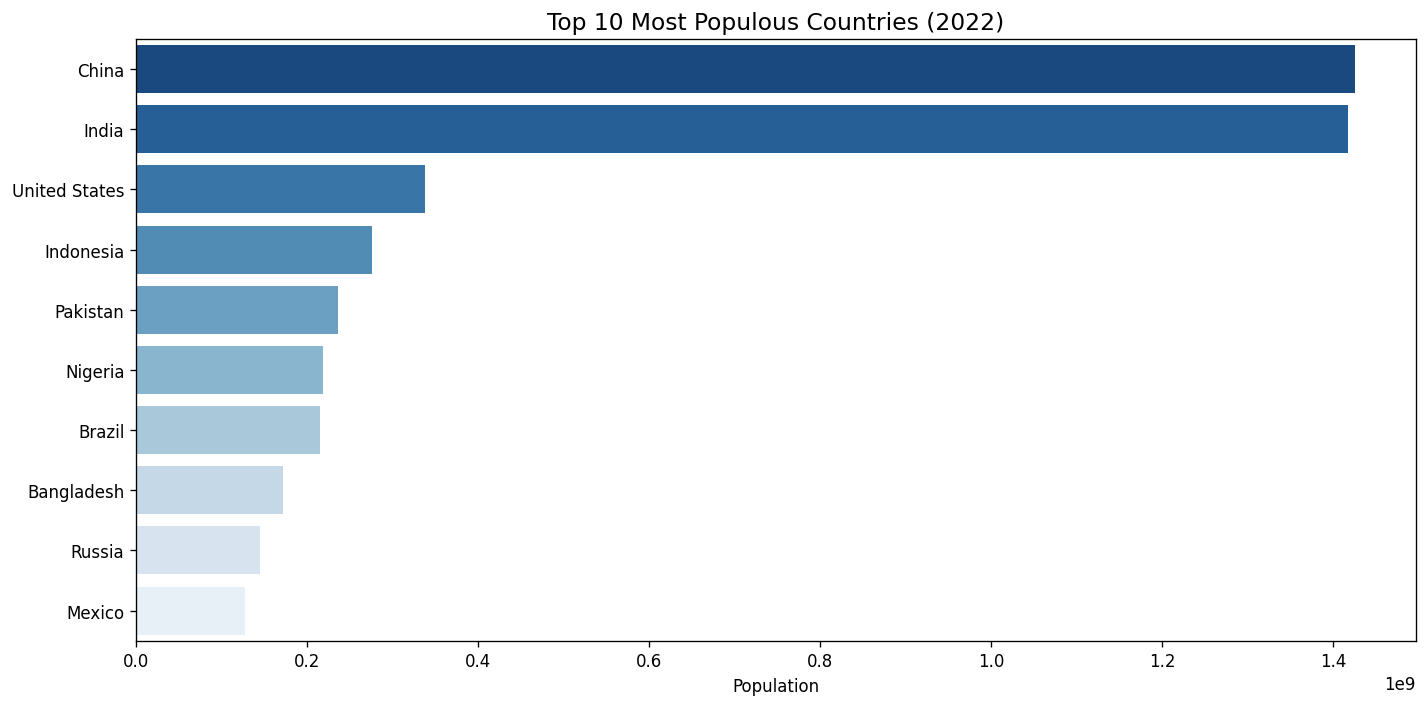

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x="2022 Population", y="Country/Territory", palette="Blues_r")
plt.title("Top 10 Most Populous Countries (2022)", fontsize=14)
plt.xlabel("Population")
plt.ylabel("")
plt.tight_layout()
plt.savefig("top10_countries.png", dpi=150)
plt.show()

## Step 5: Population by Continent (2022)
Which continents hold the most people?

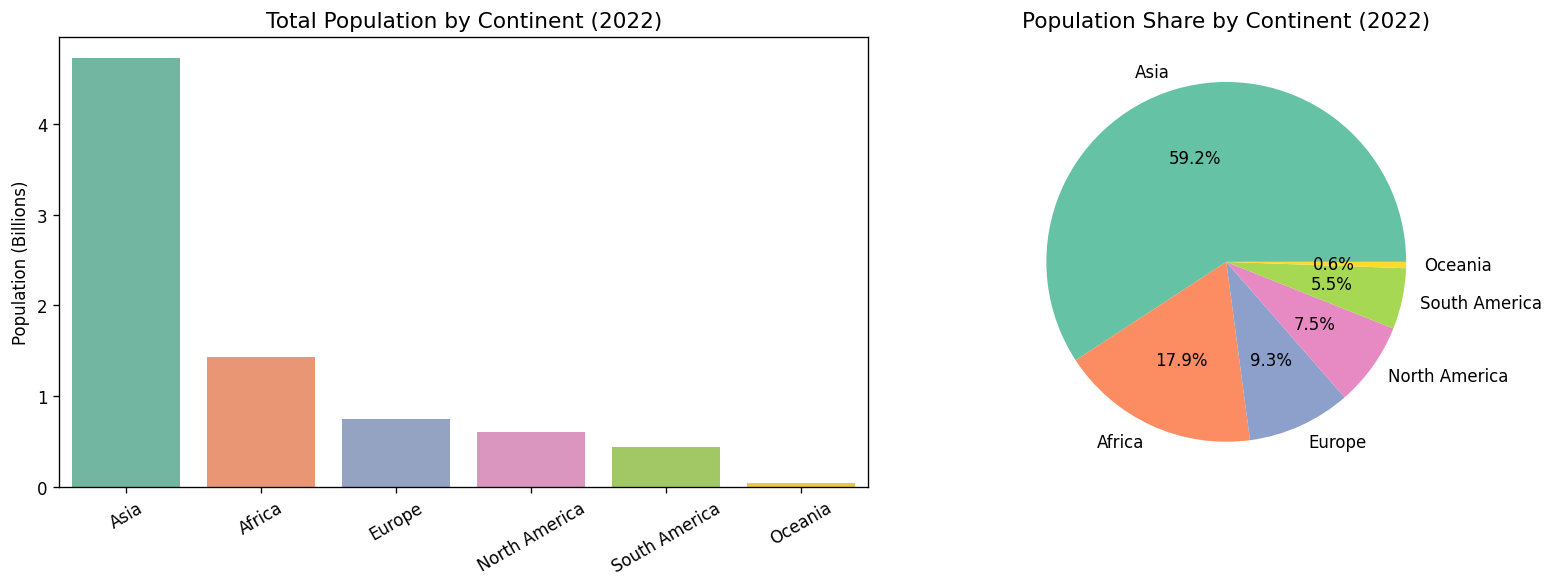

In [7]:
continent_2022 = (df_long[df_long["Year"] == 2022]
                  .groupby("Continent")["Population"]
                  .sum()
                  .sort_values(ascending=False)
                  .reset_index())

continent_2022["Population_B"] = continent_2022["Population"] / 1e9

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(data=continent_2022, x="Continent", y="Population_B",
            palette="Set2", ax=axes[0])
axes[0].set_title("Total Population by Continent (2022)", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Population (Billions)")
axes[0].tick_params(axis="x", rotation=30)

# Pie chart
axes[1].pie(continent_2022["Population"], labels=continent_2022["Continent"],
            autopct="%1.1f%%", colors=sns.color_palette("Set2"))
axes[1].set_title("Population Share by Continent (2022)", fontsize=13)

plt.tight_layout()
plt.savefig("continent_population.png", dpi=150)
plt.show()

## Step 6: Population Trends Over Time — Top 10 Countries
How did the most populous countries grow from 1970 to 2022?

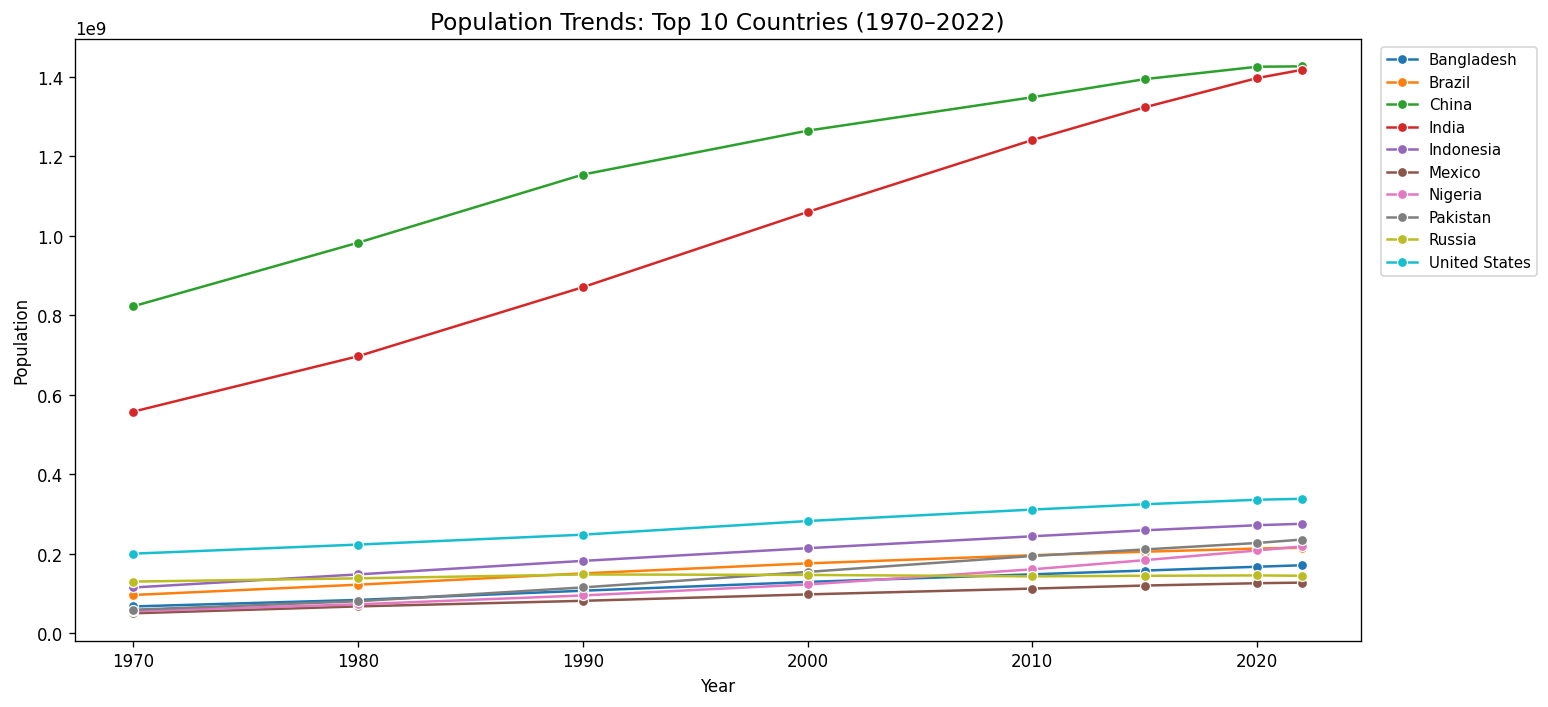

In [8]:
top10_names = top10["Country/Territory"].tolist()
top10_trend = df_long[df_long["Country/Territory"].isin(top10_names)]

plt.figure(figsize=(13, 6))
sns.lineplot(data=top10_trend, x="Year", y="Population",
             hue="Country/Territory", marker="o", palette="tab10")
plt.title("Population Trends: Top 10 Countries (1970–2022)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("top10_trends.png", dpi=150)
plt.show()

## Step 7: Decade-over-Decade Growth Rates
Which countries grew fastest across three decades?

In [9]:
growth_df = df[["Country/Territory","Continent",
                "1990 Population","2000 Population",
                "2010 Population","2022 Population"]].copy()

growth_df["Growth_1990_2000_%"] = ((growth_df["2000 Population"] - growth_df["1990 Population"])
                                    / growth_df["1990 Population"] * 100).round(2)
growth_df["Growth_2000_2010_%"] = ((growth_df["2010 Population"] - growth_df["2000 Population"])
                                    / growth_df["2000 Population"] * 100).round(2)
growth_df["Growth_2010_2022_%"] = ((growth_df["2022 Population"] - growth_df["2010 Population"])
                                    / growth_df["2010 Population"] * 100).round(2)

# Show top 10 fastest growing 2010-2022
top_growers = growth_df.nlargest(10, "Growth_2010_2022_%")[
    ["Country/Territory","Continent","Growth_1990_2000_%","Growth_2000_2010_%","Growth_2010_2022_%"]
].reset_index(drop=True)

print("Top 10 fastest growing countries (2010–2022):")
top_growers

Top 10 fastest growing countries (2010–2022):


,Country/Territory,Continent,Growth_1990_2000_%,Growth_2000_2010_%,Growth_2010_2022_%
0,Jordan,Asia,45.27,37.09,62.83
1,Oman,Asia,29.91,22.94,58.79
2,Niger,Africa,38.85,43.23,57.43
3,Qatar,Asia,46.25,165.27,57.29
4,Mayotte,Africa,71.83,33.02,53.98
5,Turks and Caicos Islands,North America,60.08,58.59,53.75
6,Equatorial Guinea,Africa,47.13,59.79,53.03
7,Angola,Africa,38.60,42.52,52.32
8,DR Congo,Africa,35.09,36.56,49.13
9,Chad,Africa,41.74,44.02,49.00


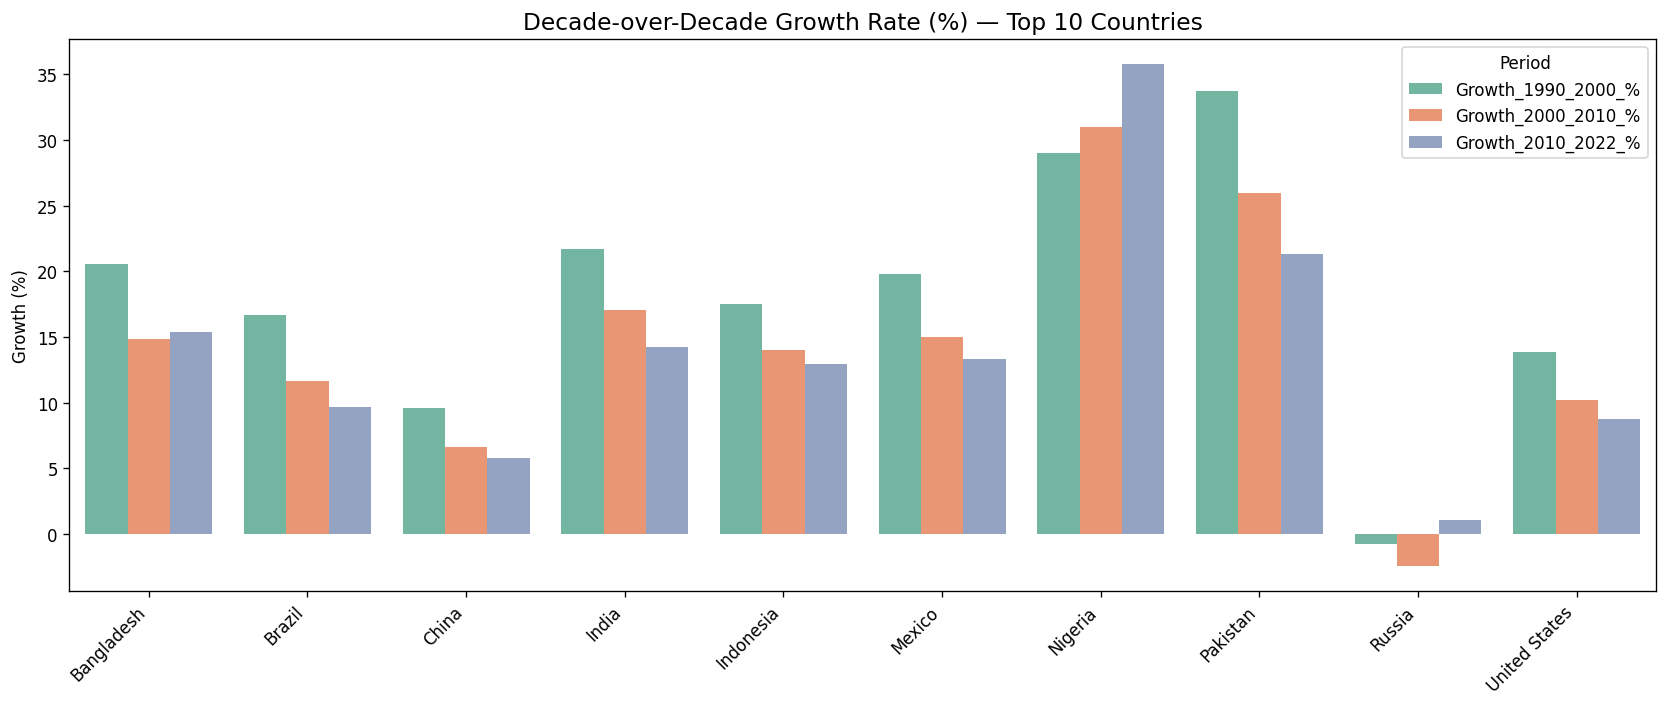

In [10]:
# Growth rates for top 10 most populous (for dashboard consistency)
top10_growth = growth_df[growth_df["Country/Territory"].isin(top10_names)].copy()
top10_growth_melted = top10_growth.melt(
    id_vars="Country/Territory",
    value_vars=["Growth_1990_2000_%","Growth_2000_2010_%","Growth_2010_2022_%"],
    var_name="Decade", value_name="Growth%"
)

plt.figure(figsize=(14, 6))
sns.barplot(data=top10_growth_melted, x="Country/Territory", y="Growth%",
            hue="Decade", palette="Set2")
plt.title("Decade-over-Decade Growth Rate (%) — Top 10 Countries", fontsize=14)
plt.xlabel("")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Period")
plt.tight_layout()
plt.savefig("decade_growth.png", dpi=150)
plt.show()

## Step 8: Growth Rate Distribution by Continent
Are some continents growing faster than others?

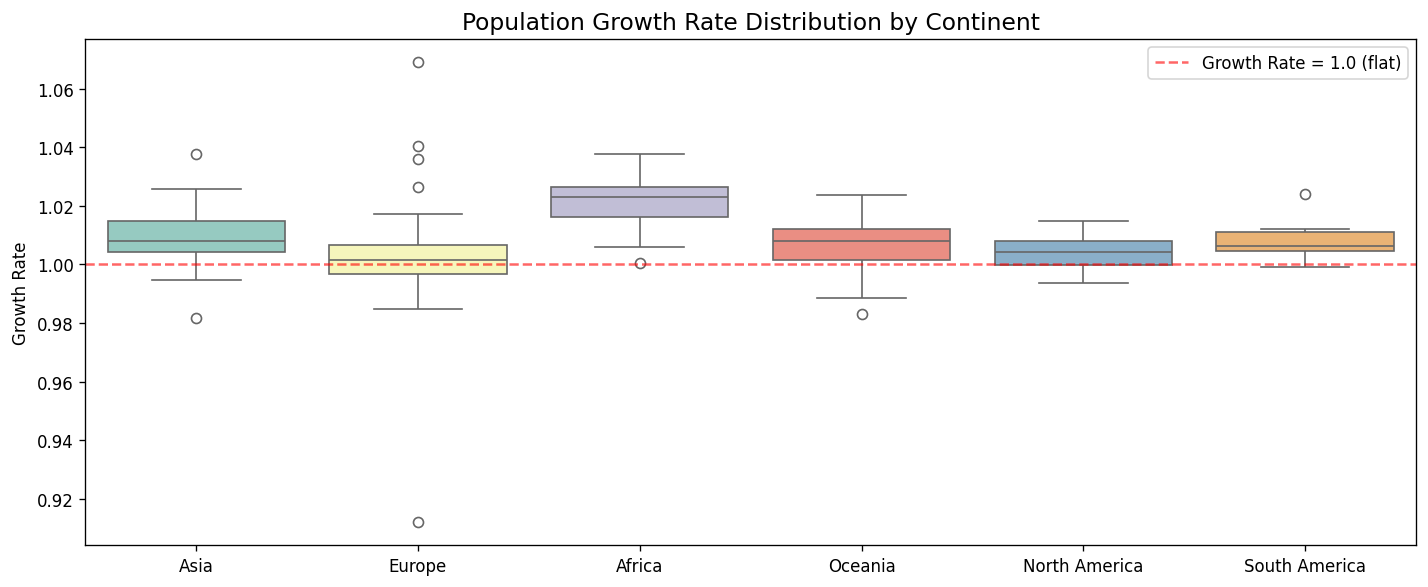


Median growth rate by continent:
Continent
Africa           1.0231
Asia             1.0081
Oceania          1.0079
South America    1.0063
North America    1.0042
Europe           1.0015
Name: Growth Rate, dtype: float64


In [11]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="Continent", y="Growth Rate", palette="Set3")
plt.axhline(y=1.0, color="red", linestyle="--", alpha=0.6, label="Growth Rate = 1.0 (flat)")
plt.title("Population Growth Rate Distribution by Continent", fontsize=14)
plt.xlabel("")
plt.ylabel("Growth Rate")
plt.legend()
plt.tight_layout()
plt.savefig("growth_rate_continent.png", dpi=150)
plt.show()

print("\nMedian growth rate by continent:")
print(df.groupby("Continent")["Growth Rate"].median().sort_values(ascending=False).round(4))

## Step 9: ARIMA Forecasting — India vs China to 2040
India recently surpassed China. We forecast both to 2040 using ARIMA on snapshot data.

**Train:** 1970–2010 | **Test:** 2015–2022 | **Forecast:** 2023–2040

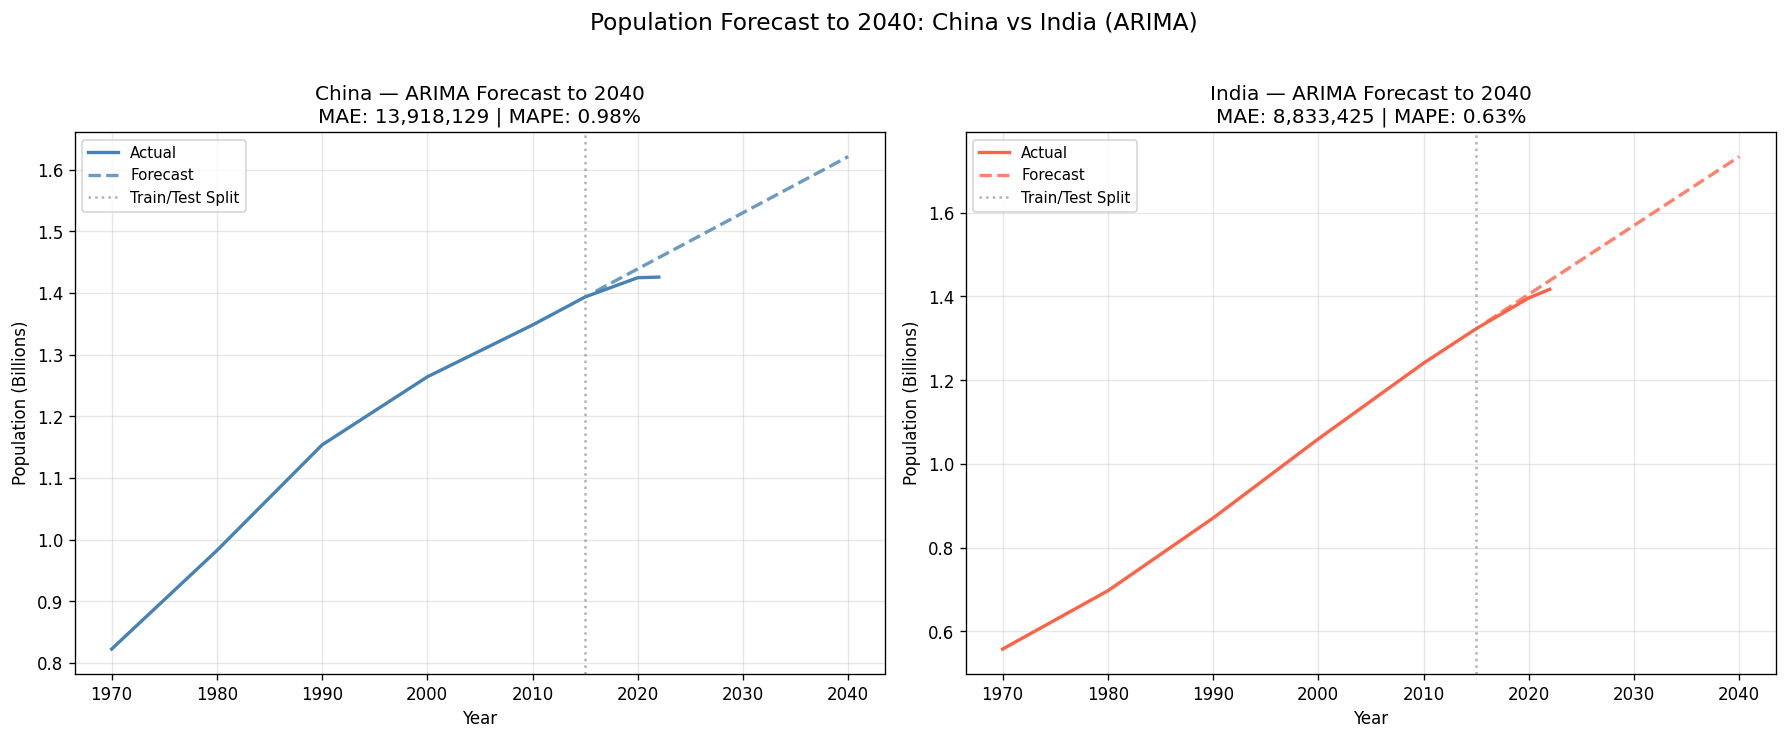

In [12]:
def forecast_country(country_name, color, ax):
    sub = df_long[df_long["Country/Territory"] == country_name].sort_values("Year")
    ts_snapshots = sub.set_index("Year")["Population"]

    # Interpolate snapshots to annual data
    all_years = pd.RangeIndex(start=1970, stop=2023, step=1)
    ts_annual = ts_snapshots.reindex(all_years).interpolate(method="linear")

    train = ts_annual[ts_annual.index <= 2015]
    test  = ts_annual[ts_annual.index >  2015]

    model = ARIMA(train, order=(1, 2, 1))
    fit   = model.fit()

    fc        = fit.forecast(steps=25)  # 2016-2040
    fc_series = pd.Series(fc.values, index=range(2016, 2041))

    test_pred = fc_series[fc_series.index <= 2022]
    mae  = mean_absolute_error(test.values, test_pred.values)
    mape = np.mean(np.abs((test.values - test_pred.values) / test.values)) * 100

    ax.plot(ts_annual.index, ts_annual / 1e9, color=color, linewidth=2, label="Actual")
    ax.plot(fc_series.index, fc_series / 1e9, linestyle="--", color=color,
            alpha=0.8, linewidth=2, label="Forecast")
    ax.axvline(x=2015, color="gray", linestyle=":", alpha=0.6, label="Train/Test Split")
    ax.set_title(f"{country_name} — ARIMA Forecast to 2040\nMAE: {mae:,.0f} | MAPE: {mape:.2f}%", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Population (Billions)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    return fc_series

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fc_china = forecast_country("China",  "steelblue", axes[0])
fc_india = forecast_country("India",  "tomato",    axes[1])
plt.suptitle("Population Forecast to 2040: China vs India (ARIMA)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("arima_forecast.png", dpi=150)
plt.show()

In [13]:
print("Forecasted Populations in 2040:")
print(f"  China: {fc_china[2040]/1e9:.2f} Billion")
print(f"  India: {fc_india[2040]/1e9:.2f} Billion")

Forecasted Populations in 2040:
  China: 1.62 Billion
  India: 1.73 Billion


## Step 10: Export Data for Power BI
Export clean CSVs ready to load into the Power BI dashboard.

In [14]:
# Main long format fact table
df_long.to_csv("population_long_format.csv", index=False)

# Growth rates table
growth_df.to_csv("decade_growth_rates.csv", index=False)

# Forecast table — China and India to 2040
forecast_export = pd.DataFrame({
    "Year": list(fc_china.index) + list(fc_india.index),
    "Country/Territory": ["China"] * len(fc_china) + ["India"] * len(fc_india),
    "Forecasted_Population": list(fc_china.values) + list(fc_india.values)
})
forecast_export.to_csv("population_forecast_2040.csv", index=False)

# Continent summary
continent_summary = (df_long.groupby(["Continent","Year"])["Population"]
                     .sum().reset_index())
continent_summary.to_csv("continent_population_by_year.csv", index=False)

print("Exported:")
print("  population_long_format.csv")
print("  decade_growth_rates.csv")
print("  population_forecast_2040.csv")
print("  continent_population_by_year.csv")
print("\nAll done. Load these into Power BI.")

Exported:
  population_long_format.csv
  decade_growth_rates.csv
  population_forecast_2040.csv
  continent_population_by_year.csv

All done. Load these into Power BI.
